# Embedding test data case 
Now that we've extracted the LU C program and the test data in the same format, we can embed them in the same embedding space. 
For now, it makes most sense to make 5 TSNE plots (but with one TSNE fit) so there is one plot per student. 
We can also filter out duplicates in the test set by looking at the course_code variable. 

In [1]:
# Load sBERT tokenizer 
import nltk 
nltk.download('punkt') 
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize 
from sentence_transformers import SentenceTransformer 
import numpy as np 
import torch 

model_name = "sentence-transformers/all-mpnet-base-v2"   # sBERT model
model = SentenceTransformer(model_name)
tokenizer = model.tokenizer
max_tokens = 256  # model limit

[nltk_data] Downloading package punkt to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/NLP/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
import itertools
import re
from typing import List, Dict, Set
import pandas as pd 

def normalize(title: str) -> str:
    """Normalize text"""
    if pd.isna(title):
        return ""
    
    title = str(title)
    title = title.lower() # Convert to lowercase
    title = title.replace('&', 'and') # Replace '&' with 'and'
    title = re.sub(r'[^\w\s-]', ' ', title) # Remove special characters but keep spaces and hyphens
    title = re.sub(r'\b(and|or|the|of|for|in|to|a|an|with|at|by)\b', ' ', title) # Remove common conjunctions as standalone words
    title = re.sub(r'\s+', ' ', title).strip() # Clean up extra spaces
    title = re.sub(r's\b', '', title) # Remove trailing 's' for plurals 
    return title

In [3]:
# read data files 
df_LU_C = pd.read_csv('/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/data/LU/C/all_mandatory_courses.csv')
df_test = pd.read_csv('/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/data/test_courses.csv')
#print(df_test['course_code'])
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]

In [4]:
# merge dfs 
df_combined = pd.concat([df_test,df_LU_C], ignore_index=True)
print(df_combined.keys())
course_descriptions = df_combined['description']

Index(['title', 'credits', 'level', 'description', 'topics',
       'learning_outcomes', 'prerequisites', 'examination_methods',
       'course_code'],
      dtype='object')


In [22]:
import re 
def embed_paragraphs(model, tokenizer, paragraphs):
    if len(paragraphs) == 0:
        return np.zeros(model.get_sentence_embedding_dimension())
    
    embeddings = model.encode(paragraphs, convert_to_numpy=True, normalize_embeddings=True)
    return np.mean(embeddings, axis=0)

def embed_paragraphs2(model, tokenizer, paragraphs):
    if len(paragraphs) == 0:
        return np.zeros(model.get_sentence_embedding_dimension())
    else: 
        paragraphs = [normalize(paragraph) for paragraph in paragraphs]
    
    embeddings = model.encode(paragraphs, convert_to_numpy=True, normalize_embeddings=False)
    return np.mean(embeddings, axis=0)

def split_sentences(text): 
    sentences = re.split(r'\.\s+(?=[A-Z])', text)
    
    # Re-add the period to each sentence (except maybe last if you want)
    sentences = [s.strip() + '.' for s in sentences if s]
    
    #for s in sentences:
      #  print(s)
    return sentences 

# now extract the embeddings for all courses 
course_embs = [] 
course_names = [] 
for i,course in enumerate(course_descriptions): #[0:23]: 
    if isinstance(course,str):            
        out2 = embed_paragraphs2(model,tokenizer, split_sentences(course)) 
        course_embs.append(out2) 
        course_names.append(df_combined['title'][i])
    #else: 
    #    course_embs.append([])

In [23]:
# also extract LO and topic embs 
# now extract the embeddings for all courses 
LO_embs = [] 
course_names2 = [] 
for i,course in enumerate(df_combined['learning_outcomes']): #[0:23]: 
    if isinstance(course,str):         
        split = split_sentences(course)
        out2 = embed_paragraphs(model,tokenizer,split ) 
        LO_embs.append(out2) 
        course_names2.append(df_combined['title'][i])

topic_embs = [] 
course_names3 = [] 
for i,course in enumerate(df_combined['topics']): #[0:23]: 
    if isinstance(course,str):         
        split = split_sentences(course)
        out2 = embed_paragraphs(model,tokenizer,split ) 
        topic_embs.append(out2) 
        course_names3.append(df_combined['title'][i])
        

In [34]:
print(course_names[:30])
print(course_names[28])
print(course_names2[:30])
print(course_names3[:30])

['Systems Security', 'Smart Phone Sensing', 'Research in Cyber Security – Hacking Lab', 'Error Correcting Codes', 'Distributed Data Systems', 'Introduction to Computer Graphics', 'First-Year Spanish', 'CMPM 203 Computational Media Methods', 'CMPM 290K Social and Emotional Approaches to Human Computer Interaction', 'CSE 80A Universal Access: Disability, Technology, and Society', 'CSE 163 Data Programming for Visualization', 'CSE 185E Technical Writing for Computer Science and Engineering', 'Creative Strategies for Designing Interactive Media', 'CSE160 Introduction to Computer Graphics', 'CSE103 Computational Models', 'Applied Machine Learning', 'ITAL2 First-Year Italian', 'CSE140 Artificial Intelligence', 'CSE118 Mobile Applications', 'HAVC143E History of Design: The Objects of Technology, 1850-The Present', 'Patterns in Software Engineering (IN2081)', 'Real-Time Systems, Exercise Session (IN2060)', 'Techniques in Artificial Intelligence (IN2062)', 'Visual Data Analytics (IN2026, IN8019

In [27]:
print(np.array(LO_embs).shape)
print(np.array(course_embs).shape)

(204, 768)
(188, 768)


In [50]:
from sklearn.metrics.pairwise import cosine_similarity
embs = np.array(course_embs) 
cos_sims = [] 
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]
student = student_list[0]
print('check courses: ',[course_names[0][i] for i in student])
los = df_combined['learning_outcomes'] 
topics = df_combined['topics']
lo_embs = np.array(LO_embs)
t_embs = np.array(topic_embs)

labels = [] 
for i in [student[4]]: 
    print(i)
    arr = embs[i]
    print(course_names[i])
    print(los[i])
    print(topics[i])
    cos_sim = cosine_similarity(arr[np.newaxis,:],embs[28:])
    #cos_sims.append(max(cos_sim))
    lo_emb = lo_embs[i]
    top_emb = t_embs[i]
    cos_sim2 = cosine_similarity(lo_emb[np.newaxis,:],lo_embs[29:])
    cos_sim3 = cosine_similarity(top_emb[np.newaxis,:],t_embs[29:])
    chosen = np.argmax(cos_sim)
    chosen2 = np.argmax(cos_sim2) # normally we would do this in one sum but some do not have LOs 
    chosen3 = np.argmax(cos_sim3) 
    print(course_names[28+chosen])
    print(max(max(cos_sim)))
    print(course_names2[29+chosen2])
    print(28+chosen)
    print(29+chosen2)
    print(29+chosen3)
    print(max(max(cos_sim2)))
    print(course_names3[29+chosen3])
    print(max(max(cos_sim3)))
    labels.append(29+chosen) 
    #top_3 = np.argpartition(total_cos_sim, -3)[-3:]
    break
 
#print(cos_sims[0].shape)

check courses:  ['S', 'y', 's', 't', 'e']
4
Distributed Data Systems
['Explain the objectives and functions of distributed computing systems.', 'Describe the architecture and operation of distributed computing systems.', 'Explain how distributed computing systems can process data.', 'Implement complex operations of modern distributed computing systems in real-world use-cases such as distributed learning and graph processing.', 'Analyse the trade-offs inherent in the design of distributed computing systems (performance, efficiency, scalability, reliability, availability, fault-tolerance).']
['distributed computing systems', 'data systems']
Distributed Systems
0.6980382
Distributed Systems
139
154
88
0.8102304
Internet Inside
0.72713184


In [64]:
#print(course_descriptions)
course_descriptions[i]
course_descriptions[26+chosen]

"The purpose of this course is to be an eye-opener as to how technology can create possibilities for people with disabilities to increase their independence, quality of life and ability to participate in society. Knowledge of the human being and the ability to understand different people's lives will be important characteristics of an engineer to be able to participate in society's aspirations for diversity. Diversity and inclusion are part of sustainable development, and link to several of the goals in Agenda 2030, eg 3: good health and well-being, goal 4: good education for all, goal 5: gender equality, goal 8: decent work and economic growth, goal 10: reducing inequality, goal 11: sustainable cities and communities, goal 16: peaceful and inclusive communities."

In [51]:
print(course_names[139])
print(los[154])
print(topics[88])

Distributed Systems
['display basic knowledge of: different types of distributed systems and their properties', 'display basic knowledge of: failure and recovery in distributed systems', 'display basic knowledge of: models and abstractions for distributed systems', 'display basic knowledge of: distributed models of logical time', 'display basic knowledge of: distributed algorithms and protocols', 'display basic knowledge of: and distributed state and computing', 'be able to reason about properties of distributed systems', 'be able to use concepts and abstractions to model distributed systems and to express their behaviour', 'be able to use fundamental distributed algorithms and protocols in managing resources, sharing state, maintaining distributed state, and coordinate distributed computation', 'be able to apply the conceptual knowledge to the implementation of distributed algorithms on a variety of platforms', 'be able to judge the suitability of models and platforms for distributed 

In [6]:
print(len(course_embs))
print(len(course_names))

188
188


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


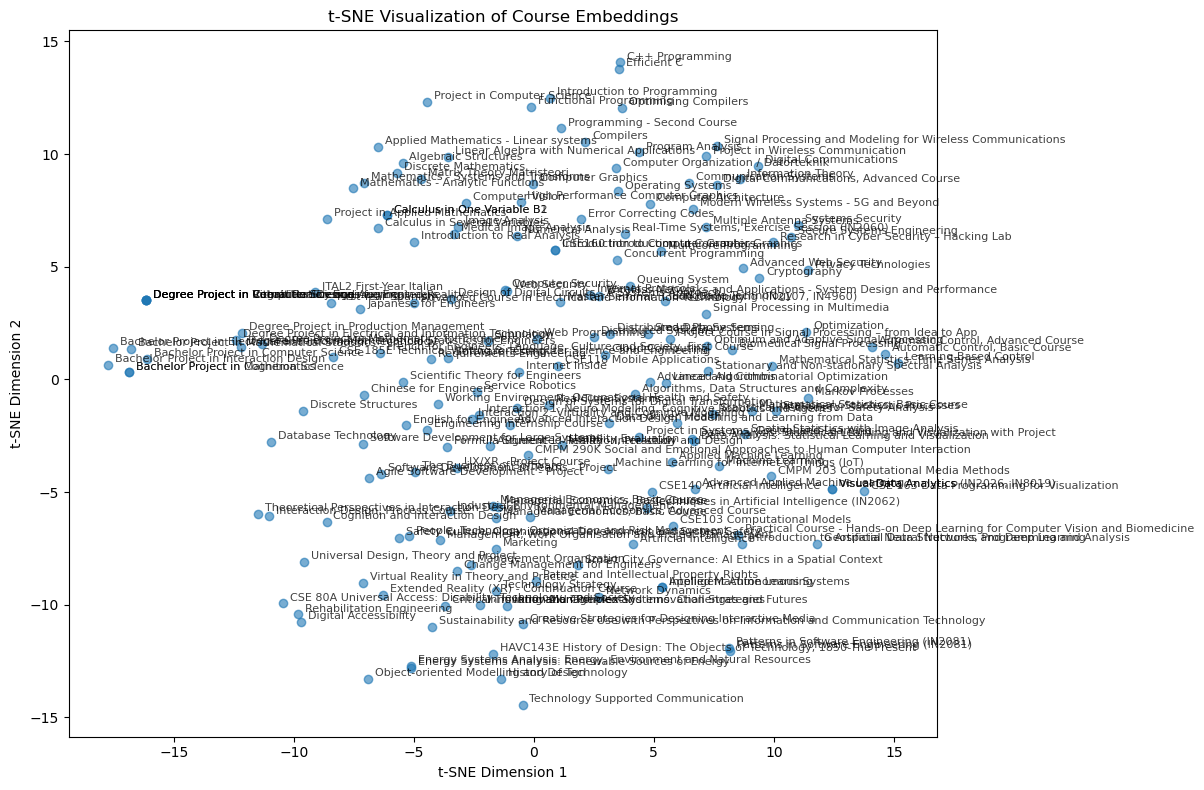

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assume:
# course_embs = np.array(...)  # shape: (n_courses, embedding_dim)
# course_names = list of strings, length = n_courses

# Step 1: Reduce dimensionality with t‑SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(course_embs)-1))
embeddings_2d = tsne.fit_transform(np.array(course_embs))

# Step 2: Plot
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)

# Step 3: Annotate each point with the course title
for i, name in enumerate(course_names):
    if i < len(course_embs): 
        plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.75,
                 xytext=(5, 2),
                 textcoords='offset points')

plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

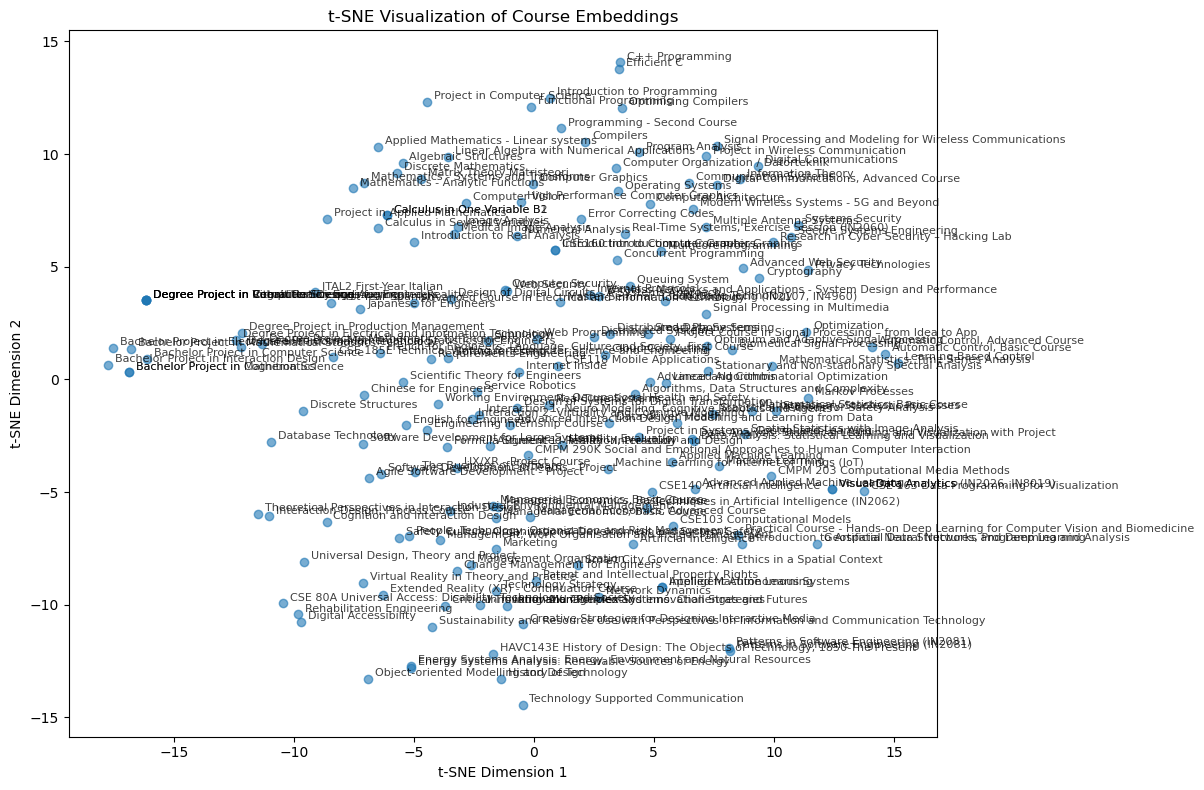

In [8]:
# Step 2: Plot
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
#course_names = [x.values for x in course_names]
#print(course_names[:10])
# Step 3: Annotate each point with the course title
for i, name in enumerate(course_names):
    if i < len(course_embs): 
        plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.75,
                 xytext=(5, 2),
                 textcoords='offset points')

plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

check courses:  ['S', 'y', 's', 't', 'e']


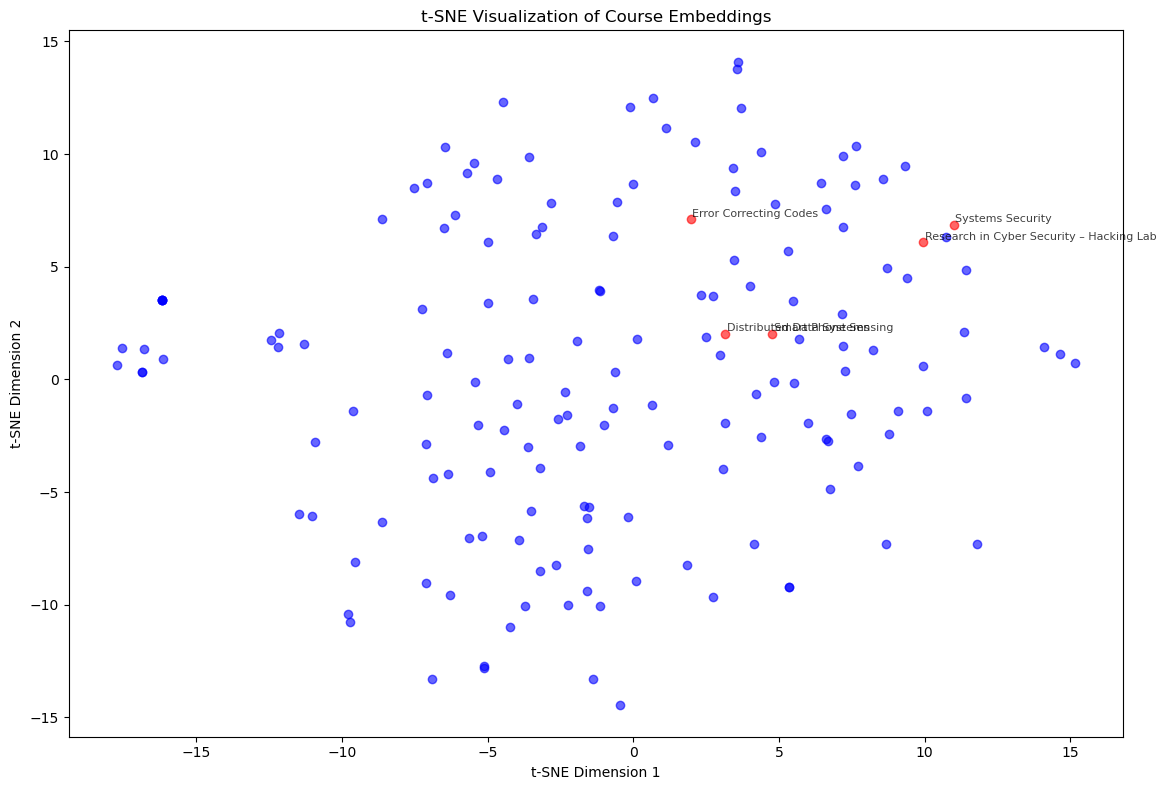

In [11]:
# now analyze one student
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]
student = student_list[0]
print('check courses: ',[course_names[0][i] for i in student])

# now visualize t-sne 
plt.figure(figsize=(12, 8))
for i, name in enumerate(course_names):
    if i in student: 
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
        plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.75,
                 xytext=(1, 2),
                 textcoords='offset points')
    if i < len(course_embs) and i >= 29: # starts at 29 
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='b')
        #plt.annotate(name, 
        #         (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        #         fontsize=8,
         #        alpha=0.75,
         #        xytext=(5, 2),
         #        textcoords='offset points')

plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

In [9]:
# now find the closest matches and indicate those course names 
from sklearn.metrics.pairwise import cosine_similarity
embs = np.array(course_embs) 
cos_sims = [] 
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]
student = student_list[0]
print('check courses: ',[course_names[0][i] for i in student])

labels = [] 
for i in student: 
    print(i)
    arr = embs[i]
    print(course_names[i])
    cos_sim = cosine_similarity(arr[np.newaxis,:],embs[29:])
    cos_sims.append(cos_sim)
    chosen = np.argmax(cos_sims[i])
    print(course_names[29+chosen])
    labels.append(29+chosen) 
    #top_3 = np.argpartition(total_cos_sim, -3)[-3:]
 
print(cos_sims[0].shape)

check courses:  ['S', 'y', 's', 't', 'e']
0
Systems Security
Secure Systems Engineering
1
Smart Phone Sensing
Project Course in Signal Processing – from Idea to App
2
Research in Cyber Security – Hacking Lab
Secure Systems Engineering
3
Error Correcting Codes
Communication Systems
4
Distributed Data Systems
Distributed Systems
(1, 159)


In [12]:
#!pip install matplot2tikz

In [19]:
# now visualize t-sne 
from adjustText import adjust_text
#import matplot2tikz 

plt.figure(figsize=(12, 8))
texts = [] 
lines = [] 
added_labels = []
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
for i in student: 
    name = course_names[i]
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
    # Store text objects instead of plotting immediately
    texts.append(plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))

    if labels[i] not in added_labels: 
        added_labels.append(labels[i])
        texts.append(plt.annotate(course_names[labels[i]], 
                 (embeddings_2d[labels[i], 0], embeddings_2d[labels[i], 1]),
                     fontsize=8,
                     alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))
    plt.scatter(embeddings_2d[labels[i], 0], embeddings_2d[labels[i], 1], alpha=0.6,color='y') # not going to be visible 
    xo = np.array([embeddings_2d[i, 0],embeddings_2d[labels[i], 0]])
    yo = np.array([embeddings_2d[i, 1],embeddings_2d[labels[i], 1]])
    line, = plt.plot(xo, yo, linestyle='dotted', color='gray')
    lines.append(line)
        
adjust_text(texts, 
           objects=lines,
            expand_points=(0.25, 0.25),
            force_points = (3,3))
plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
#matplot2tikz.save("tsne_student1.tex")
#plt.savefig('tsne_plot.pgf', bbox_inches='tight')
plt.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Looks like you are using an old matplotlib version.
               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


AttributeError: 'LatexManager' object has no attribute 'latex'

In [17]:
def generate_tsne_tikz_for_input(embeddings_2d, student_indices, labels_array, 
                                   course_names, filename="tsne_figure.tex", 
                                   scale=12.0, padding=0.1):
    """
    Generate a TikZ figure WITHOUT document wrapper - can be used with \input{}
    """
    
    # Normalize and scale all points
    all_points = embeddings_2d
    x_min, x_max = all_points[:, 0].min(), all_points[:, 0].max()
    y_min, y_max = all_points[:, 1].min(), all_points[:, 1].max()
    
    # Add padding
    x_range = x_max - x_min
    y_range = y_max - y_min
    x_min -= x_range * padding
    x_max += x_range * padding
    y_min -= y_range * padding
    y_max += y_range * padding
    
    def scale_point(x, y):
        x_scaled = scale * (x - x_min) / (x_max - x_min)
        y_scaled = scale * (y - y_min) / (y_max - y_min)
        return x_scaled, y_scaled
    
    # Collect unique label indices
    unique_labels = set()
    for i in student_indices:
        unique_labels.add(labels_array[i])
    unique_labels = list(unique_labels)
    
    # Generate TikZ code (no document wrapper)
    tikz = []
    tikz.append(r"\begin{tikzpicture}[scale=0.8, every node/.style={font=\tiny},")
    tikz.append(r"    point/.style={circle, draw, inner sep=0pt, minimum size=4pt},")
    tikz.append(r"    rounded box/.style={draw, fill=white, fill opacity=0.7, text opacity=1, rounded corners, inner sep=2pt, font=\tiny},")
    tikz.append(r"    student box/.style={draw=red!50, fill=white, fill opacity=0.7, text opacity=1, rounded corners, inner sep=2pt, font=\tiny},")
    tikz.append(r"    label box/.style={draw=gold!50, fill=white, fill opacity=0.7, text opacity=1, rounded corners, inner sep=2pt, font=\tiny}")
    tikz.append(r"]")
    
    # Draw axes
    tikz.append(r"  % Axes")
    tikz.append(rf"  \draw[->,thick] ({-0.5},{-0.5}) -- ({scale+0.5},{-0.5}) node[right] {{t-SNE Dimension 1}};")
    tikz.append(rf"  \draw[->,thick] ({-0.5},{-0.5}) -- ({-0.5},{scale+0.5}) node[above] {{t-SNE Dimension 2}};")
    
    # Title
    tikz.append(rf"  \node[font=\bfseries\large] at ({scale/2},{scale+0.8}) {{t-SNE Visualization of Course Embeddings}};")
    
    # Plot all background points (blue, alpha=0.6)
    tikz.append(r"\n  % Background points (all courses)")
    bg_points = []
    for i in range(len(embeddings_2d)):
        if i not in student_indices and i not in unique_labels:
            x, y = scale_point(embeddings_2d[i, 0], embeddings_2d[i, 1])
            bg_points.append(f"    ({x:.2f},{y:.2f})")
    
    if bg_points:
        tikz.append(r"  \fill[blue!40, opacity=0.6]")
        tikz.append(r"  plot coordinates {")
        tikz.extend(bg_points)
        tikz.append(r"  } circle (2.5pt);")
    
    # Draw connecting lines first (so they're behind points)
    tikz.append(r"\n  % Connecting lines (dotted gray)")
    for i in student_indices:
        label_idx = labels_array[i]
        x_s, y_s = scale_point(embeddings_2d[i, 0], embeddings_2d[i, 1])
        x_l, y_l = scale_point(embeddings_2d[label_idx, 0], embeddings_2d[label_idx, 1])
        tikz.append(f"  \\draw[gray, dotted, line width=0.6pt, opacity=0.6] ({x_s:.2f},{y_s:.2f}) -- ({x_l:.2f},{y_l:.2f});")
    
    # Plot label points (yellow, alpha=0.6)
    tikz.append(r"\n  % Label points (yellow)")
    label_points = []
    for idx in unique_labels:
        x, y = scale_point(embeddings_2d[idx, 0], embeddings_2d[idx, 1])
        label_points.append(f"    ({x:.2f},{y:.2f})")
    
    if label_points:
        tikz.append(r"  \fill[yellow!80!orange, opacity=0.6]")
        tikz.append(r"  plot coordinates {")
        tikz.extend(label_points)
        tikz.append(r"  } circle (3.5pt);")
    
    # Plot student points (red, alpha=0.6)
    tikz.append(r"\n  % Student points (red)")
    student_points = []
    for idx in student_indices:
        x, y = scale_point(embeddings_2d[idx, 0], embeddings_2d[idx, 1])
        student_points.append(f"    ({x:.2f},{y:.2f})")
    
    if student_points:
        tikz.append(r"  \fill[red!80, opacity=0.6]")
        tikz.append(r"  plot coordinates {")
        tikz.extend(student_points)
        tikz.append(r"  } circle (3.5pt);")
    
    # Add labels
    tikz.append(r"\n  % Labels")
    
    # Add label point labels
    for idx in unique_labels:
        name = course_names[idx] if isinstance(course_names, dict) else course_names[idx]
        x, y = scale_point(embeddings_2d[idx, 0], embeddings_2d[idx, 1])
        
        if idx % 3 == 0:
            offset_x, offset_y = 0.25, 0.25
        elif idx % 3 == 1:
            offset_x, offset_y = -0.25, 0.25
        else:
            offset_x, offset_y = 0.3, -0.2
            
        tikz.append(f"  \\node[label box] at ({x+offset_x:.2f},{y+offset_y:.2f}) {{{name}}};")
    
    # Add student point labels
    for i, idx in enumerate(student_indices):
        name = course_names[idx] if isinstance(course_names, dict) else course_names[idx]
        x, y = scale_point(embeddings_2d[idx, 0], embeddings_2d[idx, 1])
        
        offset_map = {
            0: (0.3, 0.1), 1: (-0.25, -0.25), 2: (0.2, -0.3),
            3: (-0.3, 0.2), 4: (0.35, -0.1), 5: (-0.2, 0.3),
        }
        offset_x, offset_y = offset_map.get(i % len(offset_map), (0.25, 0.25))
        
        tikz.append(f"  \\node[student box] at ({x+offset_x:.2f},{y+offset_y:.2f}) {{{name}}};")
    
    # Add legend
    tikz.append(r"\n  % Legend")
    tikz.append(rf"  \begin{{scope}}[shift={{({{{scale+0.8}}},4)}}]")
    tikz.append(r"    \node[anchor=west, font=\bfseries\small] at (0,2.5) {Legend};")
    tikz.append(r"    \fill[blue!40, opacity=0.6] (0,2.0) circle (3pt);")
    tikz.append(r"    \node[anchor=west, font=\tiny] at (0.4,2.0) {All courses};")
    tikz.append(r"    \fill[red!80, opacity=0.6] (0,1.5) circle (3pt);")
    tikz.append(r"    \node[anchor=west, font=\tiny] at (0.4,1.5) {Student courses};")
    tikz.append(r"    \fill[yellow!80!orange, opacity=0.6] (0,1.0) circle (3pt);")
    tikz.append(r"    \node[anchor=west, font=\tiny] at (0.4,1.0) {Label courses};")
    tikz.append(r"    \draw[gray, dotted, line width=0.6pt] (0,0.5) -- (0.3,0.5);")
    tikz.append(r"    \node[anchor=west, font=\tiny] at (0.4,0.5) {Connections};")
    tikz.append(r"  \end{scope}")
    
    tikz.append(r"\end{tikzpicture}")
    
    # Save to file
    with open(filename, 'w') as f:
        f.write('\n'.join(tikz))
    
    print(f"✓ TikZ figure saved to {filename}")
    print(f"  - This file can be used with \\input{{{filename}}}")

# Generate the TikZ figure (no document wrapper)
generate_tsne_tikz_for_input(
    embeddings_2d=embeddings_2d,
    student_indices=student,
    labels_array=labels,
    course_names=course_names,
    filename="tsne_figure.tex",
    scale=12.0,
    padding=0.1
)

✓ TikZ figure saved to tsne_figure.tex
  - This file can be used with \input{tsne_figure.tex}


In [21]:
# Student 2 
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]
student = student_list[0]
print('check courses: ',[course_names[i] for i in student])
labels = [] 
cos_sims = [] 
for o,i in enumerate(student): 
    print(i)
    arr = embs[i]
    print(course_names[i])
    cos_sim = cosine_similarity(arr[np.newaxis,:],embs[29:])
    cos_sims.append(cos_sim)
    chosen = np.argmax(cos_sims[o])
    print(course_names[29+chosen])
    labels.append(29+chosen) 
    #top_3 = np.argpartition(total_cos_sim, -3)[-3:]
# now visualize t-sne 
from adjustText import adjust_text
plt.figure(figsize=(12, 8))
texts = [] 
lines = [] 
added_labels = []
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
for o,i in enumerate(student): 
    name = course_names[i]
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
    # Store text objects instead of plotting immediately
    texts.append(plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))

    if labels[o] not in added_labels: 
        added_labels.append(labels[o])
        texts.append(plt.annotate(course_names[labels[o]], 
                 (embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1]),
                     fontsize=8,
                     alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))
    plt.scatter(embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1], alpha=0.6,color='y') # not going to be visible 
    xo = np.array([embeddings_2d[i, 0],embeddings_2d[labels[o], 0]])
    yo = np.array([embeddings_2d[i, 1],embeddings_2d[labels[o], 1]])
    line, = plt.plot(xo, yo, linestyle='dotted', color='gray')
    lines.append(line)
        
#adjust_text(texts, 
 #          objects=lines,
 #           expand_points=(0.25, 0.25),
   #         force_points = (3,3))
plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

check courses:  ['Systems Security', 'Smart Phone Sensing', 'Research in Cyber Security – Hacking Lab', 'Error Correcting Codes', 'Distributed Data Systems']
0
Systems Security
Secure Systems Engineering
1
Smart Phone Sensing
Project Course in Signal Processing – from Idea to App
2
Research in Cyber Security – Hacking Lab
Secure Systems Engineering
3
Error Correcting Codes
Communication Systems
4
Distributed Data Systems
Distributed Systems


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


AttributeError: 'LatexManager' object has no attribute 'latex'

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Error in callback <function _draw_all_if_interactive at 0x7ff9e4518550> (for post_execute):


AttributeError: 'LatexManager' object has no attribute 'latex'

In [10]:
# Student 3 
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]
student = student_list[1]
print('check courses: ',[course_names[i] for i in student])
labels = [] 
cos_sims = [] 
for o,i in enumerate(student): 
    print(i)
    arr = embs[i]
    print(course_names[i])
    cos_sim = cosine_similarity(arr[np.newaxis,:],embs[29:])
    cos_sims.append(cos_sim)
    chosen = np.argmax(cos_sims[o])
    print(course_names[29+chosen])
    labels.append(29+chosen) 
    #top_3 = np.argpartition(total_cos_sim, -3)[-3:]
# now visualize t-sne 
from adjustText import adjust_text
plt.figure(figsize=(12, 8))
texts = [] 
lines = [] 
added_labels = []
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
for o,i in enumerate(student): 
    name = course_names[i]
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
    # Store text objects instead of plotting immediately
    texts.append(plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))

    if labels[o] not in added_labels: 
        added_labels.append(labels[o])
        texts.append(plt.annotate(course_names[labels[o]], 
                 (embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1]),
                     fontsize=8,
                     alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))
    plt.scatter(embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1], alpha=0.6,color='y') # not going to be visible 
    xo = np.array([embeddings_2d[i, 0],embeddings_2d[labels[o], 0]])
    yo = np.array([embeddings_2d[i, 1],embeddings_2d[labels[o], 1]])
    line, = plt.plot(xo, yo, linestyle='dotted', color='gray')
    lines.append(line)
        
#adjust_text(texts, 
#           objects=lines,
 #           expand_points=(0.25, 0.25),
  #          force_points = (3,3))
plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

check courses:  ['CSE 80A Universal Access: Disability, Technology, and Society', 'CMPM 290K Social and Emotional Approaches to Human Computer Interaction', 'CMPM 203 Computational Media Methods', 'Creative Strategies for Designing Interactive Media', 'Introduction to Computer Graphics', 'CSE 163 Data Programming for Visualization', 'First-Year Spanish', 'CSE 185E Technical Writing for Computer Science and Engineering']
9


NameError: name 'embs' is not defined

check courses:  ['Practical Course - Hands-on Deep Learning for Computer Vision and Biomedicine', 'Real-Time Systems, Exercise Session (IN2060)', 'Techniques in Artificial Intelligence (IN2062)', 'Master-Seminar: Cloud Computing (IN2107, IN4960)', 'Patterns in Software Engineering (IN2081)']
27
Practical Course - Hands-on Deep Learning for Computer Vision and Biomedicine
Introduction to Artificial Neural Networks and Deep Learning
21
Real-Time Systems, Exercise Session (IN2060)
Operating Systems
22
Techniques in Artificial Intelligence (IN2062)
Artificial Intelligence
24
Master-Seminar: Cloud Computing (IN2107, IN4960)
Wireless Networks and Applications - System Design and Performance
20
Patterns in Software Engineering (IN2081)
The Business of Software


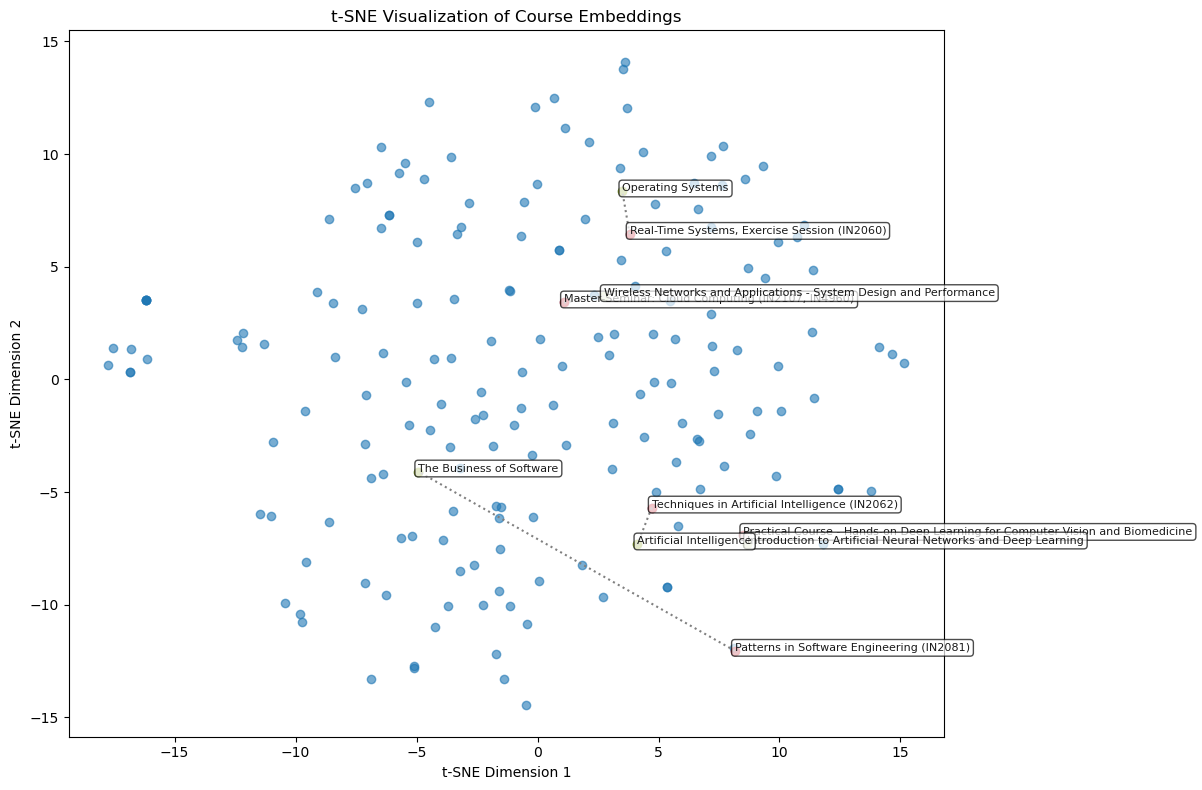

In [111]:
# Student 4 
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]
student = student_list[3]
print('check courses: ',[course_names[i] for i in student])
labels = [] 
cos_sims = [] 
for o,i in enumerate(student): 
    print(i)
    arr = embs[i]
    print(course_names[i])
    cos_sim = cosine_similarity(arr[np.newaxis,:],embs[29:])
    cos_sims.append(cos_sim)
    chosen = np.argmax(cos_sims[o])
    print(course_names[29+chosen])
    labels.append(29+chosen) 
    #top_3 = np.argpartition(total_cos_sim, -3)[-3:]
# now visualize t-sne 
from adjustText import adjust_text
plt.figure(figsize=(12, 8))
texts = [] 
lines = [] 
added_labels = []
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
for o,i in enumerate(student): 
    name = course_names[i]
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
    # Store text objects instead of plotting immediately
    texts.append(plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))

    if labels[o] not in added_labels: 
        added_labels.append(labels[o])
        texts.append(plt.annotate(course_names[labels[o]], 
                 (embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1]),
                     fontsize=8,
                     alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))
    plt.scatter(embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1], alpha=0.6,color='y') # not going to be visible 
    xo = np.array([embeddings_2d[i, 0],embeddings_2d[labels[o], 0]])
    yo = np.array([embeddings_2d[i, 1],embeddings_2d[labels[o], 1]])
    line, = plt.plot(xo, yo, linestyle='dotted', color='gray')
    lines.append(line)
        
#adjust_text(texts, 
 #          objects=lines,
 #           expand_points=(0.25, 0.25),
  #          force_points = (3,3))
plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

check courses:  ['Practical Course - Hands-on Deep Learning for Computer Vision and Biomedicine', 'Visual Data Analytics', 'Patterns in Software Engineering (IN2081)', 'Calculus in One Variable B1']
27
Practical Course - Hands-on Deep Learning for Computer Vision and Biomedicine
Introduction to Artificial Neural Networks and Deep Learning
26
Visual Data Analytics
Algorithms, Data Structures and Complexity
20
Patterns in Software Engineering (IN2081)
The Business of Software
28
Calculus in One Variable B1
Calculus in One Variable B2


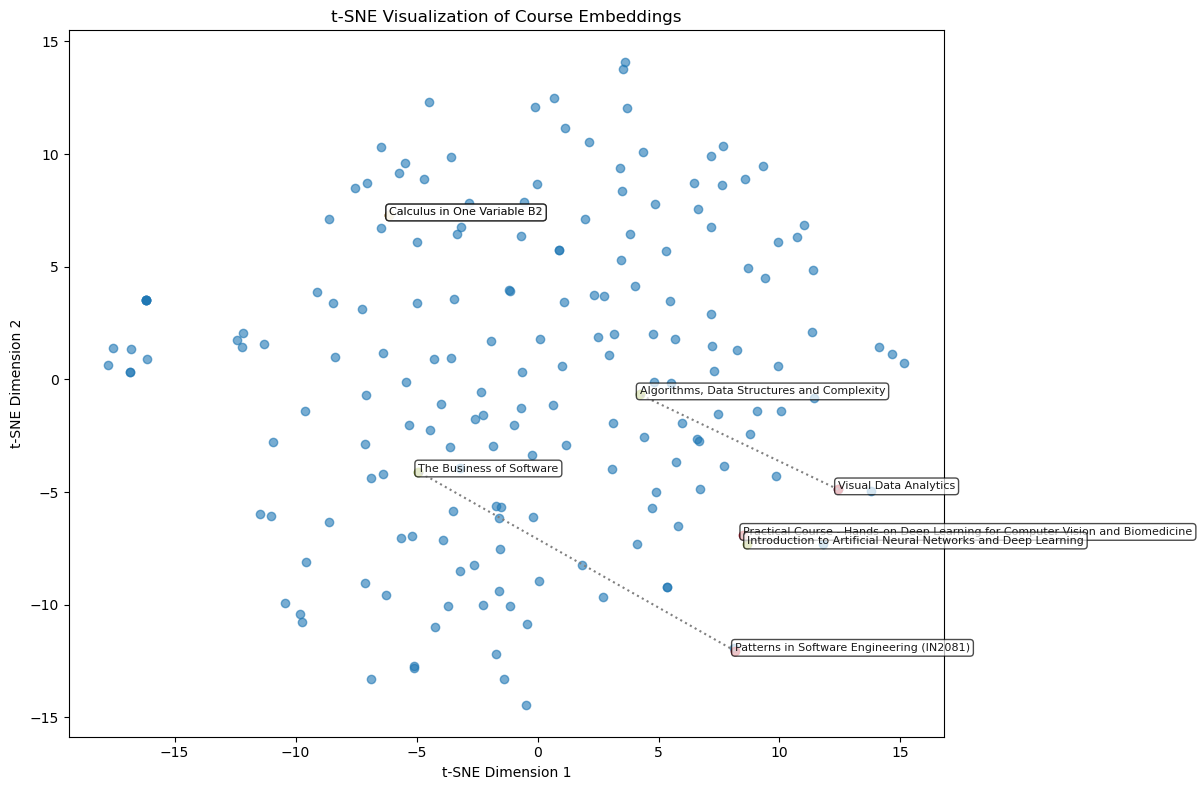

In [110]:
# Student 5 
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]
student = student_list[4]
print('check courses: ',[course_names[i] for i in student])
labels = [] 
cos_sims = [] 
for o,i in enumerate(student): 
    print(i)
    arr = embs[i]
    print(course_names[i])
    cos_sim = cosine_similarity(arr[np.newaxis,:],embs[29:])
    cos_sims.append(cos_sim)
    chosen = np.argmax(cos_sims[o])
    print(course_names[29+chosen])
    labels.append(29+chosen) 
    #top_3 = np.argpartition(total_cos_sim, -3)[-3:]
# now visualize t-sne 
from adjustText import adjust_text
plt.figure(figsize=(12, 8))
texts = [] 
lines = [] 
added_labels = []
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
for o,i in enumerate(student): 
    name = course_names[i]
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
    # Store text objects instead of plotting immediately
    texts.append(plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))

    if labels[o] not in added_labels: 
        added_labels.append(labels[o])
        texts.append(plt.annotate(course_names[labels[o]], 
                 (embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1]),
                     fontsize=8,
                     alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))
    plt.scatter(embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1], alpha=0.6,color='y') # not going to be visible 
    xo = np.array([embeddings_2d[i, 0],embeddings_2d[labels[o], 0]])
    yo = np.array([embeddings_2d[i, 1],embeddings_2d[labels[o], 1]])
    line, = plt.plot(xo, yo, linestyle='dotted', color='gray')
    lines.append(line)
        
#adjust_text(texts, 
       #    objects=lines,
         #   expand_points=(0.25, 0.25),
         #   force_points = (3,3))
plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

In [72]:
#!pip install adjustText